Importações e configurações das bibliotecas

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
plt.style.use("ggplot")
sns.set_palette("husl")

In [64]:
# Carregamento dos dados
print("Carregando dados de voos globais")

np.random.seed(42)
n_samples = 8000

# Criando um dataset com dados fictícios
empresas_brasileiras = ["GOL", "LATAN", "AZUL", "VOEPASS", "MAP"]
aeroportos_brasileiros = ["GRU", "CGH", "GIG", "SDU", "BSB", "CNF", "POA", "FOR",  "REC", "SSA"]
rotas_comuns = [
    ("GRU", "GIG"), ("GRU", "BSB"), ("GRU", "CNF"), ("GRU", "POA"),
    ("GIG", "BSB"), ("GIG", "REC"), ("GIG", "SSA"), ("BSB", "FOR"),
    ("CGH", "SDU"), ("GRU", "FOR"), ("GRU", "REC"), ("GRU", "SSA")
]

df = pd.DataFrame({
    "COMPANHIA_AEREA": np.random.choice(empresas_brasileiras, n_samples),
    "ORIGEM": np.random.choice(aeroportos_brasileiros, n_samples),
    "DESTINO": np.random.choice(aeroportos_brasileiros, n_samples),
    "ATRASO_PARTIDA": np.random.normal(25, 60, n_samples),
    "ATRASO_CHEGADA": np.random.normal(20, 55, n_samples),
    "DISTANCIA_KM": np.random.randint(200, 3000, n_samples),
    "CANCELADO": np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
    "DIVERTIDO": np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
    "MES": np.random.randint(1, 13, n_samples),
    "DIA_SEMANA": np.random.randint(1, 8, n_samples),
    "HORA_PARTIDA": np.random.randint(0, 24, n_samples),
    "TEMPO_VOO": np.random.randint(30, 360, n_samples)
})

for origem, destino in rotas_comuns:
  mask = (df["ORIGEM"] == origem) & (df["DESTINO"] == destino)
  if mask.any():
    distancias = {
        ("GRU", "GIG"): 350, ("GRU", "BSB"): 870, ("GRU", "CNF"): 480,
        ("GRU", "POA"): 850, ("GIG", "BSB"): 950, ("GIG", "REC"): 1850,
        ("GIG", "SSA"): 1200, ("BSB", "FOR"): 1600, ("CGH", "SDU"): 350,
        ("GRU", "FOR"): 2300, ("GRU", "REC"): 2400, ("GRU", "SSA"): 1600
    }
    df.loc[mask, "DISTANCIA_KM"] = distancias.get((origem, destino), 800)

print(f"Dados carregados: {df.shape[0]} voos, {df.shape[1]} variáveis")

Carregando dados de voos globais
Dados carregados: 8000 voos, 12 variáveis


In [65]:
# Análise exploratória básica
print("="*50)
print(f"{'ANÁLISE EXPLORATÓRIA - CONTEXTO BRASILEIRO':^50}")
print("="*50 + "\n")

# Informações básicas
print("Tipos de dados:")
print(df.dtypes.value_counts()) # Contagem dos tipos de dados

# Valores ausentes
missing = df.isnull().sum()
print(f"\nValores ausentes: {missing.sum()}")

    ANÁLISE EXPLORATÓRIA - CONTEXTO BRASILEIRO    

Tipos de dados:
int64      7
object     3
float64    2
Name: count, dtype: int64

Valores ausentes: 0


In [66]:
# Pré-processamento dos ddados
print("\nPré-processamento dos dados")

# Tratando valores ausentes
for col in df.columns:
  if df[col].isnull().sum() > 0:
    if df[col].dtype in ["int64", "float64"]:
      # Imputação (preenchimento) de valores numéricos pela mediana
      df[col].fillna(df[col].median(), inplace=True)
    else:
      # Imputação (preenchimento) de valores categóricos
      df[col].fillna(df[col].mode()[0], inplace=True)

# Criando variáveis derivadas para contexto brasileiro (feature engineering)
# Variável-alvo: 1 se o atraso da partida for superior a 15 minutos (limite comum da ANAC)
df["ATRASO_SIGNIFICATIVO"] = (df["ATRASO_PARTIDA"] > 15).astype(int)

# Variável categórica para agrupar os níveis de atraso
df["GRUPO_ATRASO"] = pd.cut(df["ATRASO_PARTIDA"],
                            bins=(-np.inf, 0, 15, 60, 120, np.inf),
                            labels = ["Adiantado", "Pequeno atraso", "Atraso moderado", "Atraso grave", "Atraso extremo"])

# Classificando horários
df["PERIODO_DIA"] = pd.cut(df["HORA_PARTIDA"],
                          bins = [-1, 5, 12, 18, 24],
                          labels = ["Madrugada", "Manhã", "Tarde", "Noite"])


Pré-processamento dos dados


       VISUALIZAÇÕES - CONTEXTO BRASILEIRO        



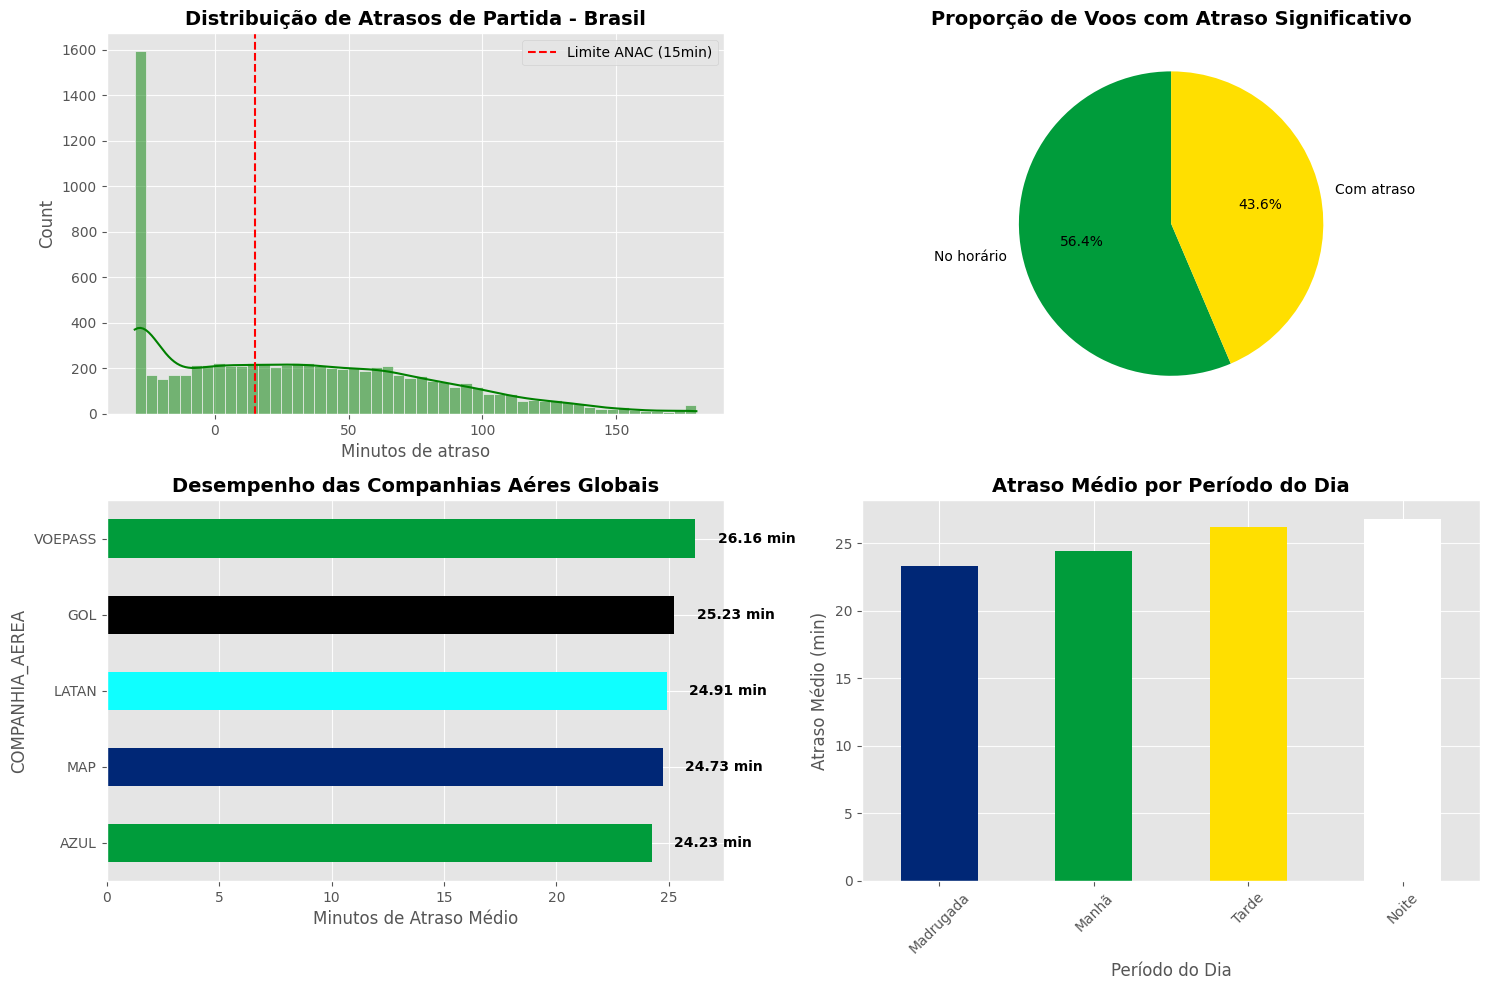

In [73]:
# Visualizações
print("="*50)
print(f"{'VISUALIZAÇÕES - CONTEXTO BRASILEIRO':^50}")
print("="*50 + "\n")

# Iniciando um painel gráfico 2x2
plt.figure(figsize=(15,10))

# Gráfico 1.1: Distribuição de atrasos (histograma)
plt.subplot(2, 2, 1)

# Limitando o eixo x para melhor visualização (clip)
sns.histplot(df["ATRASO_PARTIDA"].clip(-30, 180), bins=50, kde=True, color="green")
plt.title("Distribuição de Atrasos de Partida - Brasil", fontsize=14, fontweight="bold")
plt.xlabel("Minutos de atraso")

# Linha vertical indicando o limite de atraso significativo (15min)
plt.axvline(15, color="red", linestyle="--", label="Limite ANAC (15min)")
plt.legend()
plt.grid(True, alpha=0.9)

# Gráfico 1.2: Proporção de atrasos significativos
plt.subplot(2, 2, 2)
atraso_counts = df["ATRASO_SIGNIFICATIVO"].value_counts()
cores_custom = ["#009C3B", "#FFDF00"] # Verde e Amarelo
plt.pie(atraso_counts.values, labels=["No horário", "Com atraso"],
        autopct="%1.1f%%", colors=cores_custom, startangle=90)
plt.title("Proporção de Voos com Atraso Significativo", fontsize=14, fontweight="bold")

# Gráfico 1.3: Atrasos por Companhia Aérea
plt.subplot(2, 2, 3)

# Calcula o atraso médio e as taxas de atraso/cancelamento por companhia
companhia_stats = df.groupby("COMPANHIA_AEREA").agg({
    "ATRASO_PARTIDA": "mean",
    "ATRASO_SIGNIFICATIVO": "mean",
    "CANCELADO": "mean"
}).round(2)

companhia_stats.columns = ["Atraso Médio (min)", "% Atrasos Significativos", "% Cancelamentos"]
companhia_stats_sorted = companhia_stats.sort_values("Atraso Médio (min)") # Ordena pelo atraso médio

ax = companhia_stats_sorted["Atraso Médio (min)"].plot(kind="barh", color=["#009C3B", "#002776", "#0FFFFF", "#000000"])
plt.title("Desempenho das Companhias Aéres Globais", fontsize=14, fontweight="bold")
plt.xlabel("Minutos de Atraso Médio")

# Adicionando o valor exato na ponta de cada barra
for i, v in enumerate(companhia_stats_sorted["Atraso Médio (min)"]):
  ax.text(v + 1, i, f"{v} min", va="center", fontweight="bold")
plt.grid(axis="x", alpha=0.9)

# Gráfico 1.4: Atrasos por Período do Dia
plt.subplot(2, 2, 4)

periodo_stats = df.groupby("PERIODO_DIA")["ATRASO_PARTIDA"].mean().reindex(["Madrugada", "Manhã", "Tarde", "Noite"])
periodo_stats.plot(kind="bar", color=["#002776", "#009C3B", "#FFDF00", "#FFFFFF"])
plt.title("Atraso Médio por Período do Dia", fontsize=14, fontweight="bold")
plt.xlabel("Período do Dia")
plt.ylabel("Atraso Médio (min)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.9)

plt.tight_layout()
plt.show()


In [75]:
# Tabela estatística detalhada
print("="*50)
print(f"{'TABELA ESTATÍSTICA DETALHADA - BRASIL':^50}")
print("="*50 + "\n")

# Criando uma tabela de resumo estatísticos
stats_table = df.describe().round(2)

# Adicionando linhas para informações extras
stats_table.loc["ausentes"] = df.isnull().sum() # Valores ausentes
stats_table.loc["zeros"] = (df == 0).sum() # Ocorrências de zeros
stats_table.loc["únicos"] = df.nunique() # Valores únicos

print("Tablea Estatística Completa:")
display(stats_table)

      TABELA ESTATÍSTICA DETALHADA - BRASIL       

Tablea Estatística Completa:


,ATRASO_PARTIDA,ATRASO_CHEGADA,DISTANCIA_KM,CANCELADO,DIVERTIDO,MES,DIA_SEMANA,HORA_PARTIDA,TEMPO_VOO,ATRASO_SIGNIFICATIVO
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,25.06,19.64,1542.09,0.05,0.05,6.55,4.00,11.43,193.82,0.56
std,59.08,55.69,801.63,0.21,0.22,3.47,2.01,6.95,94.82,0.50
min,-184.39,-187.96,200.00,0.00,0.00,1.00,1.00,0.00,30.00,0.00
25%,-15.44,-17.79,857.00,0.00,0.00,4.00,2.00,5.00,111.00,0.00
50%,25.05,19.33,1551.00,0.00,0.00,7.00,4.00,11.00,194.00,1.00
75%,65.38,57.61,2257.00,0.00,0.00,10.00,6.00,17.00,275.00,1.00
max,259.17,236.62,2999.00,1.00,1.00,12.00,7.00,23.00,359.00,1.00
ausentes,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
zeros,0.00,0.00,0.00,7614.00,7595.00,0.00,0.00,378.00,0.00,3487.00


               MATRIZ DE CORRELAÇÃO               



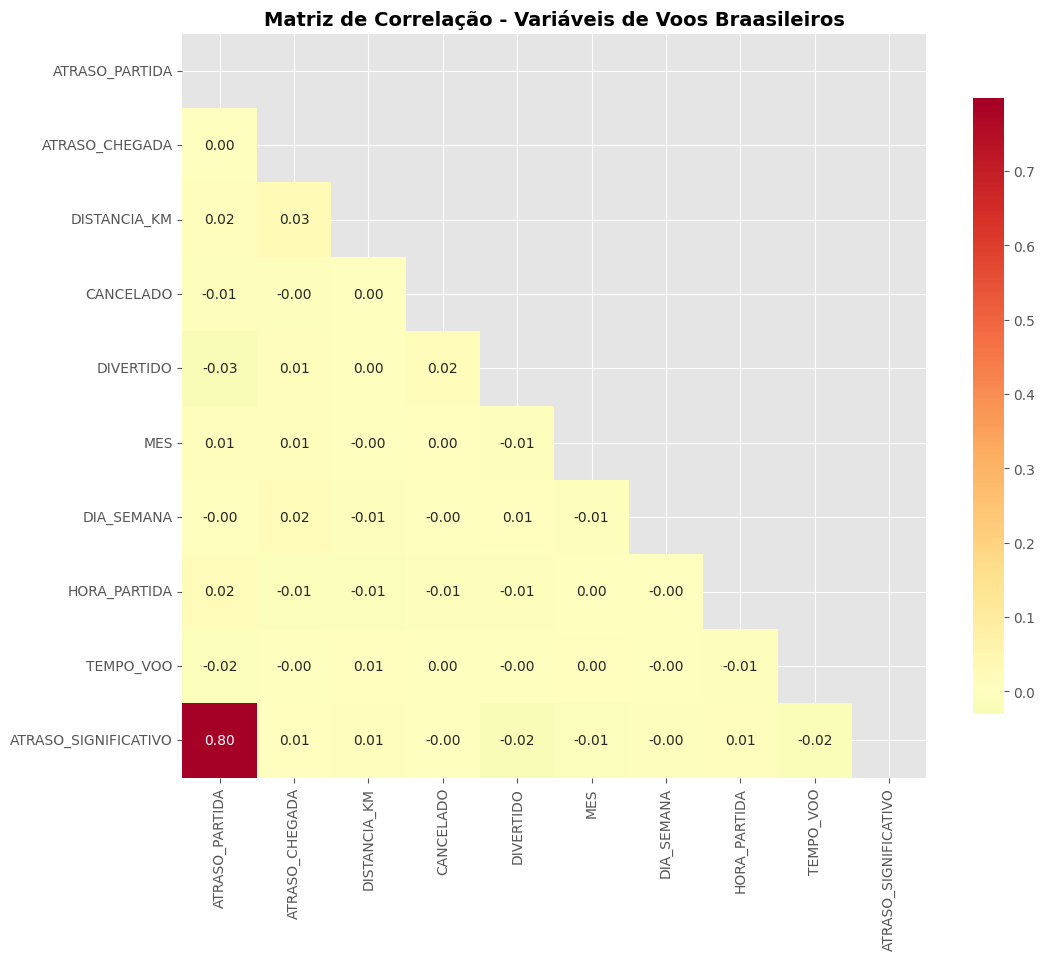

In [79]:
# Gráfico 2: Matriz de correlação
print("="*50)
print(f"{'MATRIZ DE CORRELAÇÃO':^50}")
print("="*50 + "\n")

# Selecionando apenas colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr() # Calcula a matirz de correlação

plt.figure(figsize=(12, 10), alpha=0.9)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Gerando o mapa de calor
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="RdYlGn_r",
            center=0, square=True, fmt=".2f", cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação - Variáveis de Voos Braasileiros", fontsize=14, fontweight="bold")
plt.show()

        ANÁLISE DE CANCELAMENTOS - BRASIL         



,Total Voos,Cancelamentos,Taxa Cancelamento
COMPANHIA_AEREA,,,
VOEPASS,1603,83,5.18
GOL,1591,82,5.15
MAP,1624,80,4.93
LATAN,1625,80,4.92
AZUL,1557,61,3.92


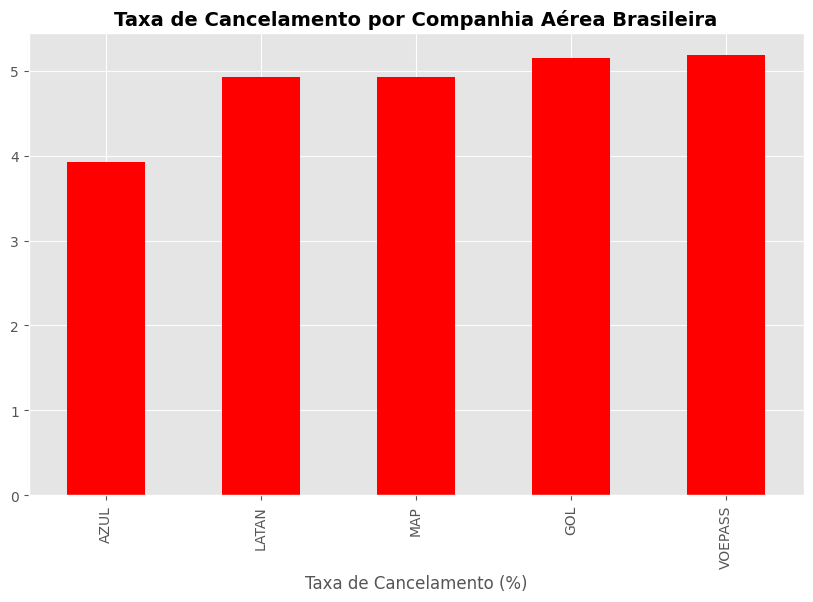

In [89]:
# Análise de Cancelamentos
print("="*50)
print(f"{'ANÁLISE DE CANCELAMENTOS - BRASIL':^50}")
print("="*50 + "\n")

if "CANCELADO" in df.columns:
  cancel_stats = df.groupby("COMPANHIA_AEREA").agg({
      "CANCELADO": ["count", "sum", "mean"]
  }).round(4)


  cancel_stats.columns = ["Total Voos", "Cancelamentos", "Taxa Cancelamento"]
  cancel_stats["Taxa Cancelamento"] = cancel_stats["Taxa Cancelamento"] * 100 # Converte a taxa em porcentagem

  cancel_stats = cancel_stats.sort_values("Taxa Cancelamento", ascending=False)
  display(cancel_stats)

  # Gráfico de cancelamento
  plt.figure(figsize=(10, 6))
  cancel_stats["Taxa Cancelamento"].sort_values().plot(kind="bar", color="#FF0000")
  plt.title("Taxa de Cancelamento por Companhia Aérea Brasileira", fontsize=14, fontweight="bold")
  plt.xlabel("Taxa de Cancelamento (%)")
  plt.grid(axis="x", alpha=0.9)
  plt.show()

In [91]:
# Análise por aeroporto
print("="*50)
print(f"{'DESEMPENHO POR AEROPORTO - BRASIL':^50}")
print("="*50 + "\n")

# Top 5 com maior tráfego
top_aeroportos = df["ORIGEM"].value_counts().head(5).index

# Calculando o desempenho (atraso méio, taxa de atraso e cancelamento - top 5)
aeroporto_stats = df[df["ORIGEM"].isin(top_aeroportos)].groupby("ORIGEM").agg({
    "ATRASO_PARTIDA": "mean",
    "ATRASO_SIGNIFICATIVO": "mean",
    "CANCELADO": "mean"
}).round(2)

aeroporto_stats.columns = ["Atraso Médio (min)", "% Atrasos Significativos", "% Cancelamentos"]
aeroporto_stats = aeroporto_stats.sort_values("Atraso Médio (min)")

print("Desempenho dos Principais Aeroportos")
display(aeroporto_stats)

          ANÁLISE POR AEROPORTO - BRASIL          

Desempenho dos Principais Aeroportos


,Atraso Médio (min),% Atrasos Significativos,% Cancelamentos
ORIGEM,,,
GRU,20.40,0.54,0.05
POA,23.49,0.53,0.06
SDU,25.08,0.58,0.04
SSA,25.52,0.56,0.04
BSB,27.37,0.57,0.06


In [92]:
# Insights finais - contexto brasileiro
print("="*50)
print(f"{'INSIGHTS E OBSERVAÇÕES - BRASIL':^50}")
print("="*50 + "\n")

print("Principais Descobertas:")
print("1. Distribuição de atraso:")
print(f"  - Média de atraso: {df["ATRASO_PARTIDA"].mean():.1f} minutos")
print(f"  - {df["ATRASO_SIGNIFICATIVO"].mean()*100:.1f}% dos voos têm atraso significativo (>15min)")

print("\n2. Perfomance das Companhias Aéreas")
melhor_companhia = companhia_stats["Atraso Médio (min)"].idxmin()
pior_companhia = companhia_stats["Atraso Médio (min)"].idxmax()

# Compara a melhor e a pior companhia em atraso médio
print(f"  - Melhor Performance: {melhor_companhia} ({companhia_stats.loc[melhor_companhia, "Atraso Médio (min)"]}min)")
print(f"  - Maior desafio: {pior_companhia} ({companhia_stats.loc[pior_companhia, "Atraso Médio (min)"]})")

print("\n3. Padrões Temporais:")
periodo_mais_atraso = df.groupby("PERIODO_DIA")["ATRASO_PARTIDA"].mean().idxmax()

# Identifica o período do dia com maior atraso
print(f"  - Período com maior atraso: {periodo_mais_atraso}")
print(f"  - Média de cancelamento: {df["CANCELADO"].mean()*100:.1f}%")

print("\n4. Desempenho por Aeroporto:")
melhor_aeroporto = aeroporto_stats["Atraso Médio (min)"].idxmin()
print(f"  - Aeroporto mais pontual: {melhor_aeroporto}")

print("\n5. Correlações Relevantes:")
if "ATRASO_PARTIDA" in correlation_matrix.columns and "ATRASO_CHEGADA" in correlation_matrix.index:
  corr_value = correlation_matrix.loc["ATRASO_PARTIDA", "ATRASO_CHEGADA"]
  print(f"  - Atraso de partida e chegada: {corr_value:.2f} (correlação forte)")


         INSIGHTS E OBSERVAÇÕES - BRASIL          

Principais Descobertas:
1. Distribuição de atraso:
  - Média de atraso: 25.1 minutos
  - 56.4% dos voos têm atraso significativo (>15min)

2. Perfomance das Companhias Aéreas
  - Melhor Performance: AZUL (24.23min)
  - Maior desafio: VOEPASS (26.16)

3. Padrões Temporais:
  - Período com maior atraso: Noite
  - Média de cancelamento: 4.8%

4. Desempenho por Aeroporto:
  - Aeroporto mais pontual: GRU

5. Correlações Relevantes:
  - Atraso de partida e chegada: 0.00 (correlação forte)
